In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
NOTEBOOK_DIR = Path.cwd()

# If the notebook is inside res_visualisation/, go one level up
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "res_visualisation" else NOTEBOOK_DIR

PORT_EVAL_DIR = ROOT / "results" / "first_hb_run" / "portfolio_evaluation"
PLOTS_DIR = PORT_EVAL_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MONTHLY_RETURNS_PATH = PORT_EVAL_DIR / "monthly_portfolio_returns.csv"

print("Reading from:", MONTHLY_RETURNS_PATH)
print("Saving plots to:", PLOTS_DIR)

# -----------------------------
# Load monthly portfolio returns
# -----------------------------
# The CSV has:
# row 1 = Method headers
# row 2 = Portfolio headers
# row 3 = a "Date" row that should be skipped
monthly = pd.read_csv(
    MONTHLY_RETURNS_PATH,
    header=[0, 1],
    skiprows=[2]
)

# First column is the date column (stored as a 2-level header)
date_col = monthly.columns[0]
monthly = monthly.set_index(date_col)
monthly.index = pd.to_datetime(monthly.index)
monthly.index.name = "Date"

# Clean up column names
monthly.columns.names = ["Method", "Portfolio"]
monthly = monthly.apply(pd.to_numeric, errors="coerce").sort_index()

# Portfolio order
portfolio_order = ["Q1", "Q2", "Q3", "Q4", "Q5"]

# Method order
method_order = [
    "Method1_Raw",
    "Method2_PostMean",
    "Method3_ProbQ5"
]
method_order = [m for m in method_order if m in monthly.columns.get_level_values("Method").unique()]

monthly.head()

Reading from: /Users/simenoiseth/Desktop/Equity_Quality_Under_Uncertainty/results/first_hb_run/portfolio_evaluation/monthly_portfolio_returns.csv
Saving plots to: /Users/simenoiseth/Desktop/Equity_Quality_Under_Uncertainty/results/first_hb_run/portfolio_evaluation/plots


Method     Method1_Raw                                          \
Portfolio           Q1        Q2        Q3        Q4        Q5   
Date                                                             
2010-01-31   -0.016588 -0.001240  0.003342  0.040661  0.015202   
2010-02-28    0.028111 -0.049086 -0.020682 -0.025666 -0.020508   
2010-03-31    0.104077  0.119293  0.054287  0.090395  0.063014   
2010-04-30   -0.075643  0.093299  0.045219  0.064293  0.006852   
2010-05-31   -0.054381 -0.094014 -0.057900 -0.061085 -0.040833   

Method     Method2_PostMean                                          \
Portfolio                Q1        Q2        Q3        Q4        Q5   
Date                                                                  
2010-01-31        -0.016280 -0.005856  0.009079  0.008669  0.023862   
2010-02-28         0.000854 -0.040867 -0.022005 -0.026727 -0.020879   
2010-03-31         0.130306  0.068591  0.053908  0.105827  0.063171   
2010-04-30         0.019091 -0.024617  0.047443  0.041857  0.017501   
2010-05-31        -0.073566 -0.088847 -0.056682 -0.069300 -0.041646   

Method     Method3_ProbQ5                                          
Portfolio              Q1        Q2        Q3        Q4        Q5  
Date                                                               
2010-01-31      -0.011050  0.026218 -0.038225  0.038092  0.023719  
2010-02-28       0.006093 -0.056719 -0.017861 -0.041862 -0.020746  
2010-03-31       0.087637  0.088878  0.102740  0.086427  0.063625  
2010-04-30      -0.005905  0.073085  0.073093  0.026904  0.017685  
2010-05-31      -0.053972 -0.072783 -0.106736 -0.067504 -0.041476

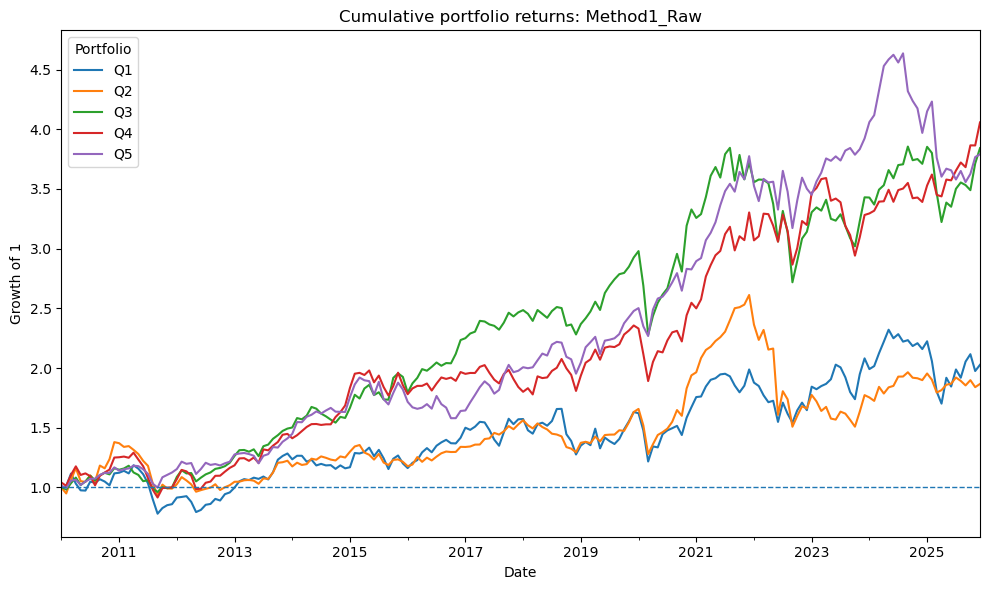

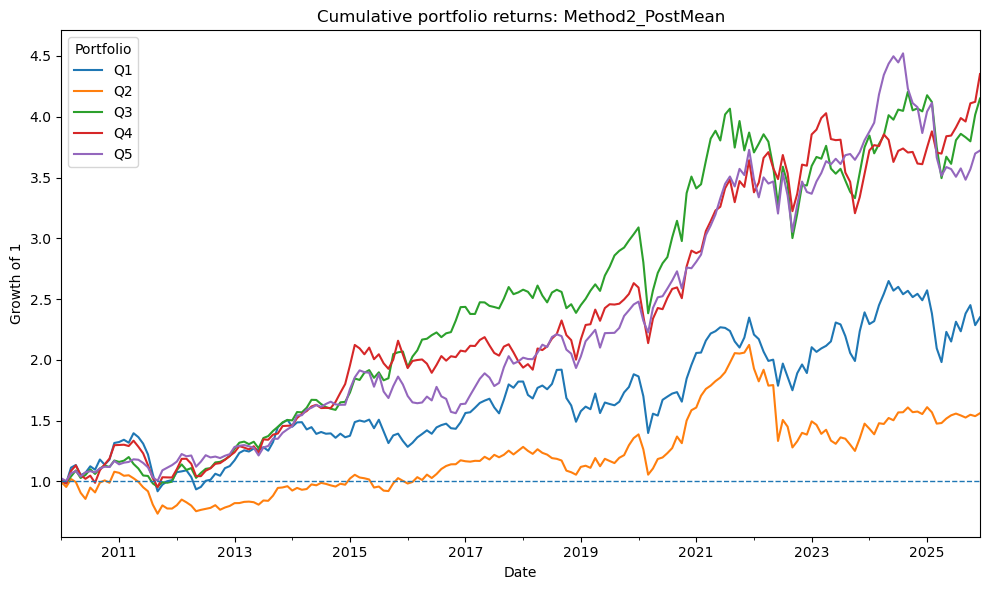

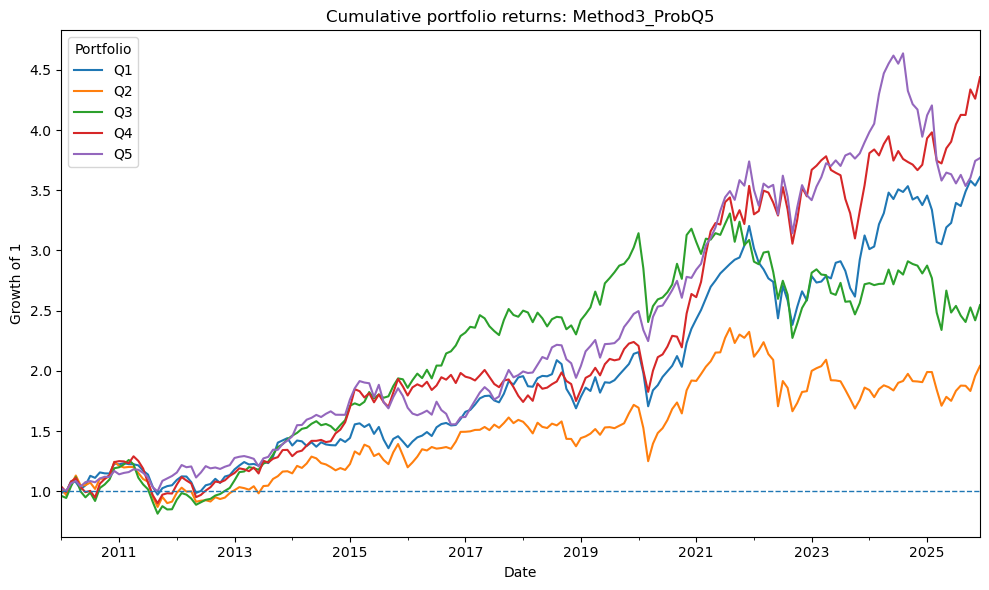

In [7]:
# -----------------------------
# Plot 1: cumulative returns for Q1-Q5 within each method
# -----------------------------
for method in method_order:
    sub = monthly[method].copy()
    sub = sub[[p for p in portfolio_order if p in sub.columns]]

    cumulative = (1 + sub).cumprod()

    ax = cumulative.plot(figsize=(10, 6))
    ax.set_title(f"Cumulative portfolio returns: {method}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Growth of 1")
    ax.axhline(1.0, linestyle="--", linewidth=1)

    plt.legend(title="Portfolio")
    plt.tight_layout()

    save_path = PLOTS_DIR / f"cumulative_returns_{method}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

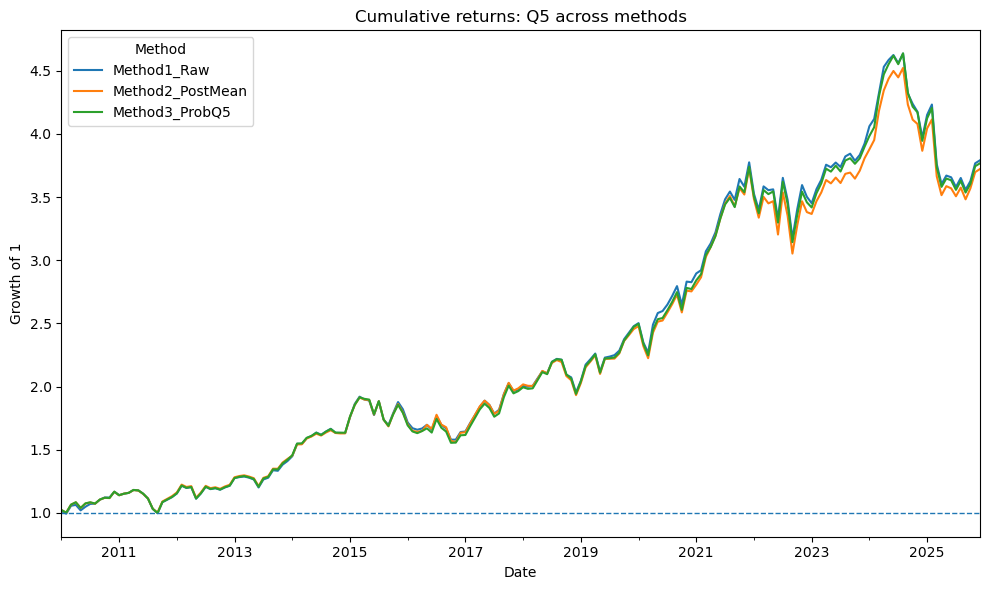

In [8]:
# -----------------------------
# Plot 2: compare Q5 across methods
# -----------------------------
q5 = monthly.xs("Q5", axis=1, level="Portfolio")
q5 = q5[method_order]

q5_cumulative = (1 + q5).cumprod()

ax = q5_cumulative.plot(figsize=(10, 6))
ax.set_title("Cumulative returns: Q5 across methods")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of 1")
ax.axhline(1.0, linestyle="--", linewidth=1)

plt.legend(title="Method")
plt.tight_layout()

save_path = PLOTS_DIR / "cumulative_returns_q5_across_methods.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

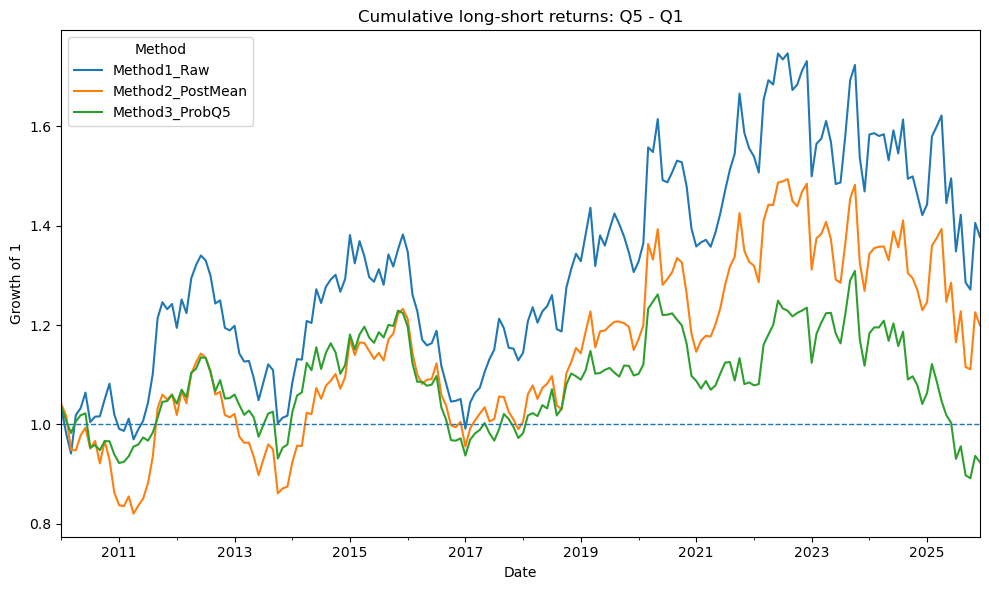

In [9]:
# -----------------------------
# Plot 3: compute and compare Q5-Q1 across methods
# -----------------------------
q1 = monthly.xs("Q1", axis=1, level="Portfolio")[method_order]
q5 = monthly.xs("Q5", axis=1, level="Portfolio")[method_order]

ls = q5 - q1
ls.columns = method_order

ls_cumulative = (1 + ls).cumprod()

ax = ls_cumulative.plot(figsize=(10, 6))
ax.set_title("Cumulative long-short returns: Q5 - Q1")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of 1")
ax.axhline(1.0, linestyle="--", linewidth=1)

plt.legend(title="Method")
plt.tight_layout()

save_path = PLOTS_DIR / "cumulative_returns_q5_minus_q1.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# -----------------------------
# Optional: average monthly returns by portfolio and method
# -----------------------------
mean_returns = (
    monthly.groupby(level="Method", axis=1)
    .mean()
)

print("Average monthly return across Q1-Q5 within each method:")
display(mean_returns.mean().to_frame("Average monthly return"))

Average monthly return across Q1-Q5 within each method:


/var/folders/j5/cllbm9vj70d8s736swfmxvfh0000gn/T/ipykernel_35502/3306843321.py:5: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly.groupby(level="Method", axis=1)


,Average monthly return
Method,
Method1_Raw,0.006639
Method2_PostMean,0.006739
Method3_ProbQ5,0.006943


In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "res_visualisation" else NOTEBOOK_DIR

PORT_EVAL_DIR = ROOT / "results" / "first_hb_run" / "portfolio_evaluation"
PLOTS_DIR = PORT_EVAL_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RISK_PATH = PORT_EVAL_DIR / "risk_adjusted_performance.csv"
ALPHA_DIFF_PATH = PORT_EVAL_DIR / "alpha_differences.csv"

risk = pd.read_csv(RISK_PATH)
alpha_diff = pd.read_csv(ALPHA_DIFF_PATH)

display(risk.head())
display(alpha_diff.head())

,Method,Portfolio,FactorModel,alpha,t_stat,p_value,r_squared,n_obs
0,Method1_Raw,Q1,CAPM,-0.002796,-1.423246,0.156305,0.601824,192.0
1,Method1_Raw,Q1,FF3,-0.002636,-1.399242,0.163388,0.606776,192.0
2,Method1_Raw,Q1,Carhart,0.000809,0.340845,0.733603,0.627848,192.0
3,Method1_Raw,Q1,FF5,-0.000779,-0.423867,0.672153,0.759795,192.0
4,Method1_Raw,Q1,FF5_MOM,0.001107,0.522132,0.602203,0.766065,192.0


,Comparison,alpha_difference,t_stat,p_value,n_obs
0,Method2_PostMean vs Method1_Raw,-0.000470,-0.114324,0.909043,192.0
1,Method3_ProbQ5 vs Method1_Raw,-0.002219,-0.564486,0.572766,192.0


In [12]:
# -----------------------------
# Choose portfolios to plot
# -----------------------------
preferred_portfolios = ["Q5-Q1", "Q5", "Q1"]
available_portfolios = risk["Portfolio"].unique().tolist()
portfolios_to_plot = [p for p in preferred_portfolios if p in available_portfolios]

if not portfolios_to_plot:
    portfolios_to_plot = sorted(available_portfolios)

print("Portfolios plotted:", portfolios_to_plot)
print("Available factor models:", risk["FactorModel"].unique().tolist())
print("Available methods:", risk["Method"].unique().tolist())

Portfolios plotted: ['Q5', 'Q1']
Available factor models: ['CAPM', 'FF3', 'Carhart', 'FF5', 'FF5_MOM']
Available methods: ['Method1_Raw', 'Method2_PostMean', 'Method3_ProbQ5']


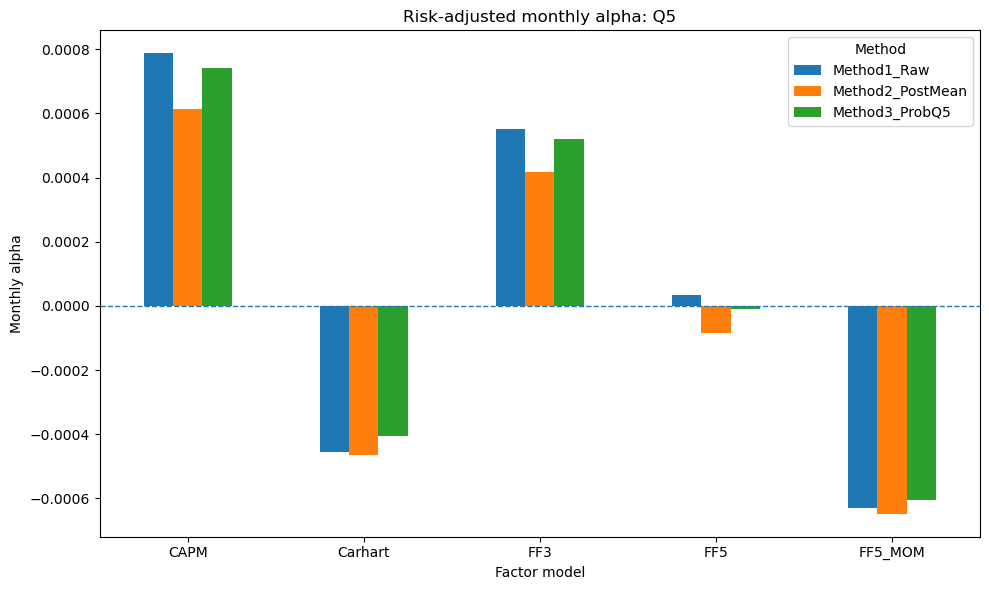

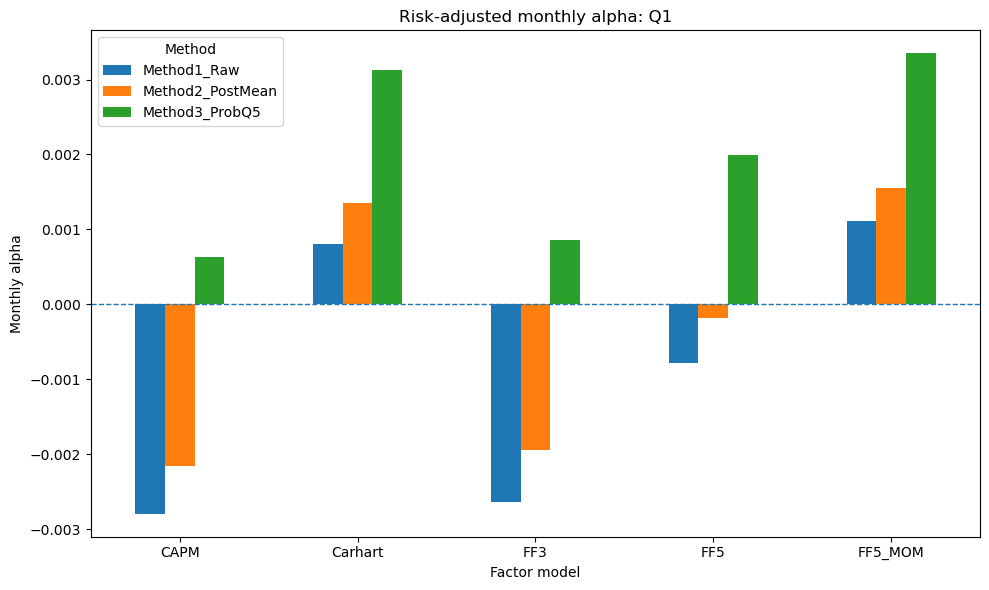

In [13]:
# -----------------------------
# Plot monthly alpha by method
# -----------------------------
for portfolio in portfolios_to_plot:
    sub = risk[risk["Portfolio"] == portfolio].copy()

    pivot_alpha = sub.pivot(index="FactorModel", columns="Method", values="alpha")

    ax = pivot_alpha.plot(kind="bar", figsize=(10, 6))
    ax.set_title(f"Risk-adjusted monthly alpha: {portfolio}")
    ax.set_xlabel("Factor model")
    ax.set_ylabel("Monthly alpha")
    ax.axhline(0, linestyle="--", linewidth=1)

    plt.xticks(rotation=0)
    plt.legend(title="Method")
    plt.tight_layout()

    save_path = PLOTS_DIR / f"alpha_monthly_{portfolio.replace('-', '_minus_')}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

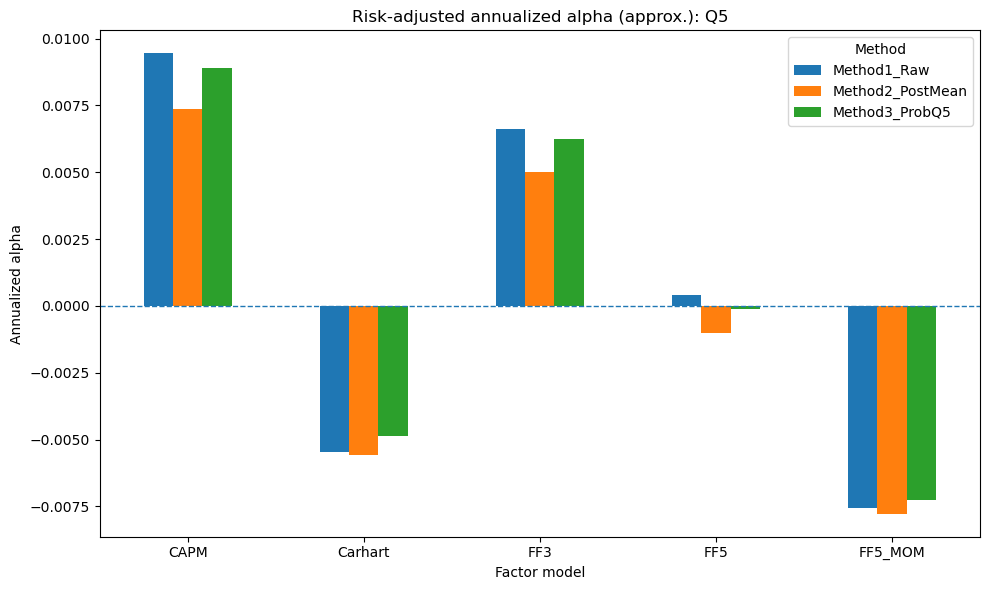

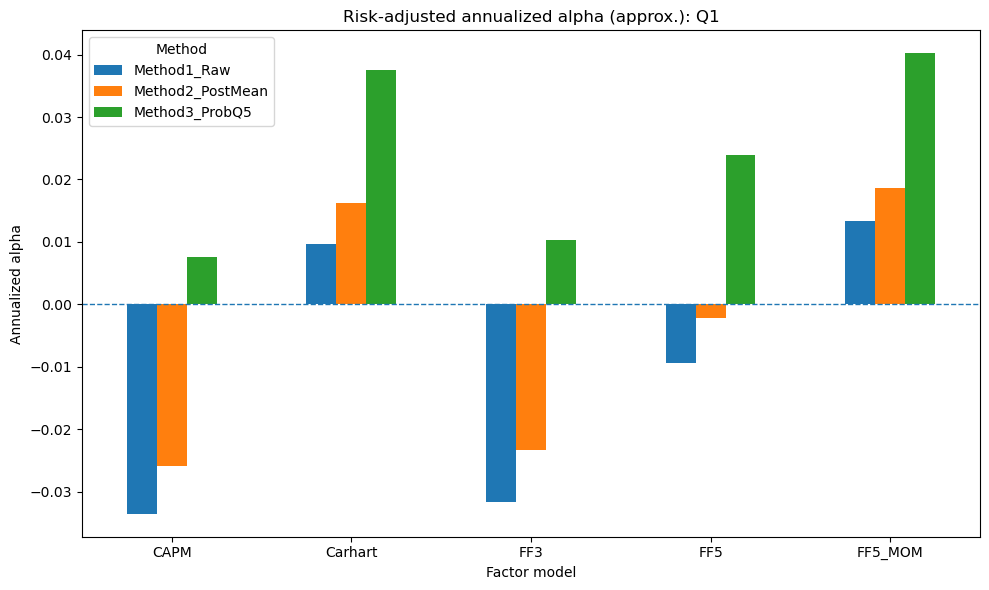

In [14]:
# -----------------------------
# Plot annualized alpha (approx. 12 * monthly alpha)
# -----------------------------
risk["alpha_annualized"] = 12 * risk["alpha"]

for portfolio in portfolios_to_plot:
    sub = risk[risk["Portfolio"] == portfolio].copy()

    pivot_alpha_ann = sub.pivot(index="FactorModel", columns="Method", values="alpha_annualized")

    ax = pivot_alpha_ann.plot(kind="bar", figsize=(10, 6))
    ax.set_title(f"Risk-adjusted annualized alpha (approx.): {portfolio}")
    ax.set_xlabel("Factor model")
    ax.set_ylabel("Annualized alpha")
    ax.axhline(0, linestyle="--", linewidth=1)

    plt.xticks(rotation=0)
    plt.legend(title="Method")
    plt.tight_layout()

    save_path = PLOTS_DIR / f"alpha_annualized_{portfolio.replace('-', '_minus_')}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

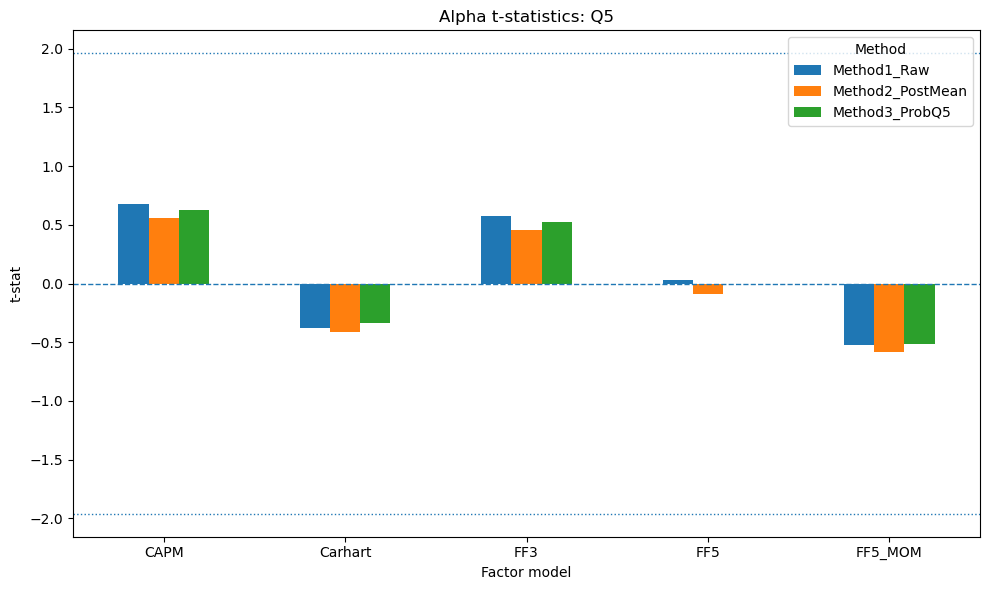

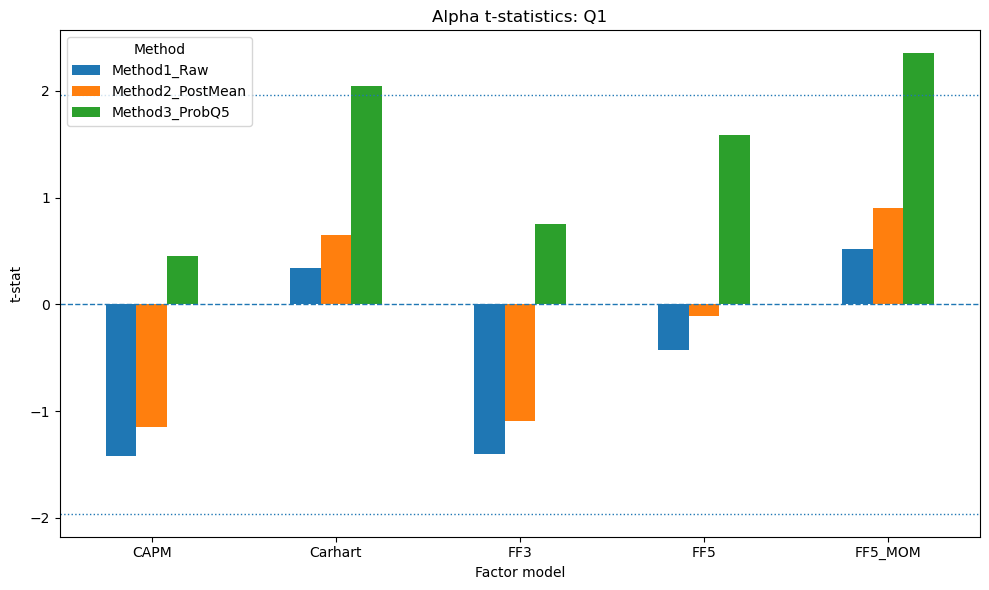

In [15]:
# -----------------------------
# Plot t-stats by method
# -----------------------------
for portfolio in portfolios_to_plot:
    sub = risk[risk["Portfolio"] == portfolio].copy()

    pivot_t = sub.pivot(index="FactorModel", columns="Method", values="t_stat")

    ax = pivot_t.plot(kind="bar", figsize=(10, 6))
    ax.set_title(f"Alpha t-statistics: {portfolio}")
    ax.set_xlabel("Factor model")
    ax.set_ylabel("t-stat")
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.axhline(1.96, linestyle=":", linewidth=1)
    ax.axhline(-1.96, linestyle=":", linewidth=1)

    plt.xticks(rotation=0)
    plt.legend(title="Method")
    plt.tight_layout()

    save_path = PLOTS_DIR / f"alpha_tstats_{portfolio.replace('-', '_minus_')}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

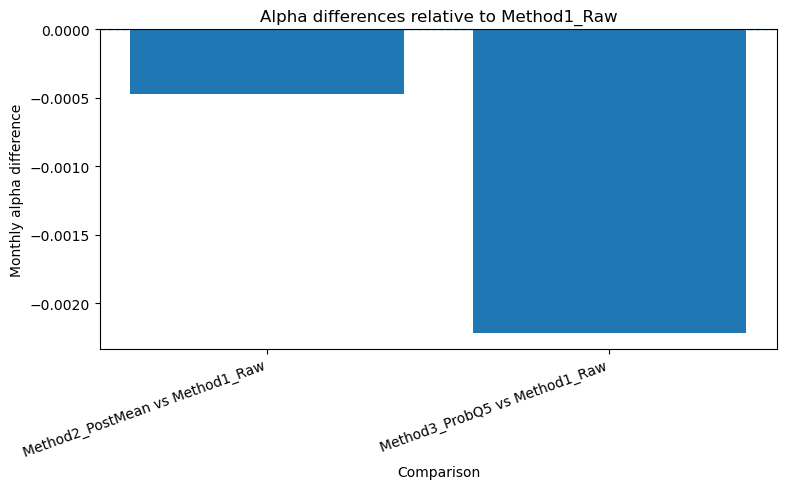

In [16]:
# -----------------------------
# Plot alpha differences vs Method1_Raw
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(alpha_diff["Comparison"], alpha_diff["alpha_difference"])
ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("Alpha differences relative to Method1_Raw")
ax.set_xlabel("Comparison")
ax.set_ylabel("Monthly alpha difference")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

save_path = PLOTS_DIR / "alpha_differences_vs_method1.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# -----------------------------
# Nice summary table
# -----------------------------
summary_cols = ["Method", "Portfolio", "FactorModel", "alpha", "t_stat", "p_value", "r_squared", "n_obs"]
summary = risk[summary_cols].copy()

if "Q5-Q1" in summary["Portfolio"].values:
    display(summary[summary["Portfolio"] == "Q5-Q1"].sort_values(["FactorModel", "Method"]))
elif "Q5" in summary["Portfolio"].values:
    display(summary[summary["Portfolio"] == "Q5"].sort_values(["FactorModel", "Method"]))
else:
    display(summary.sort_values(["Portfolio", "FactorModel", "Method"]).head(30))

,Method,Portfolio,FactorModel,alpha,t_stat,p_value,r_squared,n_obs
20,Method1_Raw,Q5,CAPM,0.000787,0.673651,0.501352,0.861019,192.0
45,Method2_PostMean,Q5,CAPM,0.000612,0.556711,0.578380,0.872561,192.0
70,Method3_ProbQ5,Q5,CAPM,0.000740,0.622882,0.534109,0.864005,192.0
22,Method1_Raw,Q5,Carhart,-0.000455,-0.380462,0.704034,0.890549,192.0
47,Method2_PostMean,Q5,Carhart,-0.000465,-0.411151,0.681432,0.895978,192.0
72,Method3_ProbQ5,Q5,Carhart,-0.000404,-0.339911,0.734305,0.890612,192.0
21,Method1_Raw,Q5,FF3,0.000552,0.574921,0.566032,0.886865,192.0
46,Method2_PostMean,Q5,FF3,0.000418,0.458055,0.647442,0.893213,192.0
71,Method3_ProbQ5,Q5,FF3,0.000521,0.520818,0.603106,0.887517,192.0
23,Method1_Raw,Q5,FF5,0.000035,0.033331,0.973447,0.906872,192.0
